In [20]:
# =====================================================================
# SEL 1: IMPORT LIBRARY & SETUP MLFLOW
# =====================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# --- ALGORITMA SESUAI HASIL PYCARET LENTERA LAUT ---
from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.ensemble import (
    RandomForestRegressor, 
    ExtraTreesRegressor,
    GradientBoostingRegressor
)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Setup MLflow Tracking
mlflow.set_tracking_uri("file:./mlruns")
print("✅ MLflow tracking siap digunakan.")

✅ MLflow tracking siap digunakan.


In [21]:
# =====================================================================
# SEL 2: LOAD DATA & PRA-PEMROSESAN
# =====================================================================
# Menentukan jalur data
base_dir = os.path.dirname(os.getcwd()) 
data_path = os.path.join(base_dir, "data", "processed", "modeling_ready.csv")

if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print("✅ Berhasil memuat data modeling_ready.csv")
else:
    print(f"❌ File TIDAK ditemukan di: {data_path}")

# Filter hanya fitur lag untuk prediktor
feature_cols = [col for col in df.columns if "_lag" in col]
X = df[feature_cols]

# Imputasi nilai kosong (NaN) dengan nilai rata-rata (mean)
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)
X_clean = pd.DataFrame(X_imputed, columns=X.columns)
print("✅ Pra-pemrosesan dan imputasi fitur selesai.")

# --- PEMETAAN MODEL TERBAIK (DIUPDATE BERDASARKAN LEADERBOARD PYCARET) ---
target_configs = {
    # 1: LinReg, 2: BayesianRidge, 3: GradientBoosting
    "wave_height": [LinearRegression(), BayesianRidge(), GradientBoostingRegressor()],
    
    # 1: LightGBM, 2: RandomForest, 3: ExtraTrees
    "wind_speed_10m": [LGBMRegressor(), RandomForestRegressor(), ExtraTreesRegressor()],
    
    # 1: ExtraTrees, 2: LightGBM, 3: XGBoost
    "ocean_current_velocity": [ExtraTreesRegressor(), LGBMRegressor(), XGBRegressor()],
    
    # 1: ExtraTrees, 2: LightGBM, 3: RandomForest
    "sea_surface_temperature": [ExtraTreesRegressor(), LGBMRegressor(), RandomForestRegressor()],
    
    # 1: GradientBoosting, 2: ExtraTrees, 3: LightGBM
    "precipitation": [GradientBoostingRegressor(), ExtraTreesRegressor(), LGBMRegressor()],
    
    # 1: RandomForest, 2: ExtraTrees, 3: LightGBM
    "visibility": [RandomForestRegressor(), ExtraTreesRegressor(), LGBMRegressor()]
}
print("✅ Konfigurasi target dan model juara siap di-training.")

✅ Berhasil memuat data modeling_ready.csv
✅ Pra-pemrosesan dan imputasi fitur selesai.
✅ Konfigurasi target dan model juara siap di-training.


In [22]:
# =====================================================================
# SEL 3: TRAINING, MLFLOW LOGGING, & TABEL METRIK
# =====================================================================
summary_list = []

print("--- MEMULAI PROSES TRAINING DAN LOGGING ---")
for target_var, models in target_configs.items():
    print(f"\n{'='*15} TRAINING TARGET: {target_var} {'='*15}")
    
    y = df[target_var]
    X_train, X_test, y_train, y_test = train_test_split(X_clean, y, test_size=0.2, random_state=123)
    
    mlflow.set_experiment(f"LenteraLaut_v3_{target_var}")
    
    for model in models:
        model_name = model.__class__.__name__
        
        # Integrasi imputer dan model ke dalam satu Pipeline
        pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='mean')), 
            ('model', model)
        ])
        
        with mlflow.start_run(run_name=f"Baseline_{model_name}"):
            pipeline.fit(X_train, y_train)
            preds = pipeline.predict(X_test)
            
            # Kalkulasi metrik evaluasi
            mae = mean_absolute_error(y_test, preds)
            rmse = np.sqrt(mean_squared_error(y_test, preds))
            r2 = r2_score(y_test, preds)
            
            # Pencatatan ke List untuk DataFrame Pandas
            summary_list.append({
                "Target Variable": target_var,
                "Algorithm": model_name,
                "MAE": mae,
                "RMSE": rmse,
                "R2": r2
            })
            
            # Pencatatan metrik dan artefak model ke MLflow
            mlflow.log_param("algorithm", model_name)
            mlflow.log_metrics({"MAE": mae, "RMSE": rmse, "R2": r2})
            mlflow.sklearn.log_model(pipeline, "model")
            
            print(f" -> [OK] {model_name} | R2: {r2:.4f} | RMSE: {rmse:.4f}")

# --- PEMBENTUKAN TABEL RINGKASAN ---
metrics_df = pd.DataFrame(summary_list)
metrics_df = metrics_df.sort_values(by=["Target Variable", "R2"], ascending=[True, False]).reset_index(drop=True)

styled_table = metrics_df.style.background_gradient(
    subset=["R2"], cmap="YlGn"
).background_gradient(
    subset=["MAE", "RMSE"], cmap="Reds"
).format({
    "R2": "{:.4f}", "MAE": "{:.4f}", "RMSE": "{:.4f}"
})

print("\n--- TABEL RINGKASAN METRIK EVALUasi (BASELINE) ---")
display(styled_table)

2026/05/21 21:19:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


--- MEMULAI PROSES TRAINING DAN LOGGING ---

=============== TRAINING TARGET: wave_height ===============


2026/05/21 21:19:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/21 21:19:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/21 21:19:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


 -> [OK] LinearRegression | R2: 0.9997 | RMSE: 0.0098
 -> [OK] BayesianRidge | R2: 0.9997 | RMSE: 0.0098


2026/05/21 21:19:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/21 21:19:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/21 21:19:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


...

2026/05/21 21:20:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/21 21:20:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


 -> [OK] RandomForestRegressor | R2: 0.6869 | RMSE: 3187.5107


2026/05/21 21:20:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/21 21:20:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/21 21:20:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/21 21:20:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

 -> [OK] ExtraTreesRegressor | R2: 0.6897 | RMSE: 3173.0561
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000394 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1998
[LightGBM] [Info] Number of data points in the train set: 3300, number of used features: 18
[LightGBM] [Info] Start training from score 9087.993939
 -> [OK] LGBMRegressor | R2: 0.6729 | RMSE: 3257.7412

--- TABEL RINGKASAN METRIK EVALUasi (BASELINE) ---


,Target Variable,Algorithm,MAE,RMSE,R2
0,ocean_current_velocity,ExtraTreesRegressor,0.0905,0.1424,0.9824
1,ocean_current_velocity,XGBRegressor,0.1055,0.1682,0.9754
2,ocean_current_velocity,LGBMRegressor,0.1045,0.1708,0.9746
3,precipitation,LGBMRegressor,0.1296,0.2842,0.5304
4,precipitation,ExtraTreesRegressor,0.1227,0.2935,0.4993
5,precipitation,GradientBoostingRegressor,0.1278,0.3024,0.4683
6,sea_surface_temperature,ExtraTreesRegressor,0.0372,0.0530,0.9979
7,sea_surface_temperature,RandomForestRegressor,0.0419,0.0564,0.9977
8,sea_surface_temperature,LGBMRegressor,0.0427,0.0569,0.9976
9,visibility,ExtraTreesRegressor,2053.6233,3173.0561,0.6897


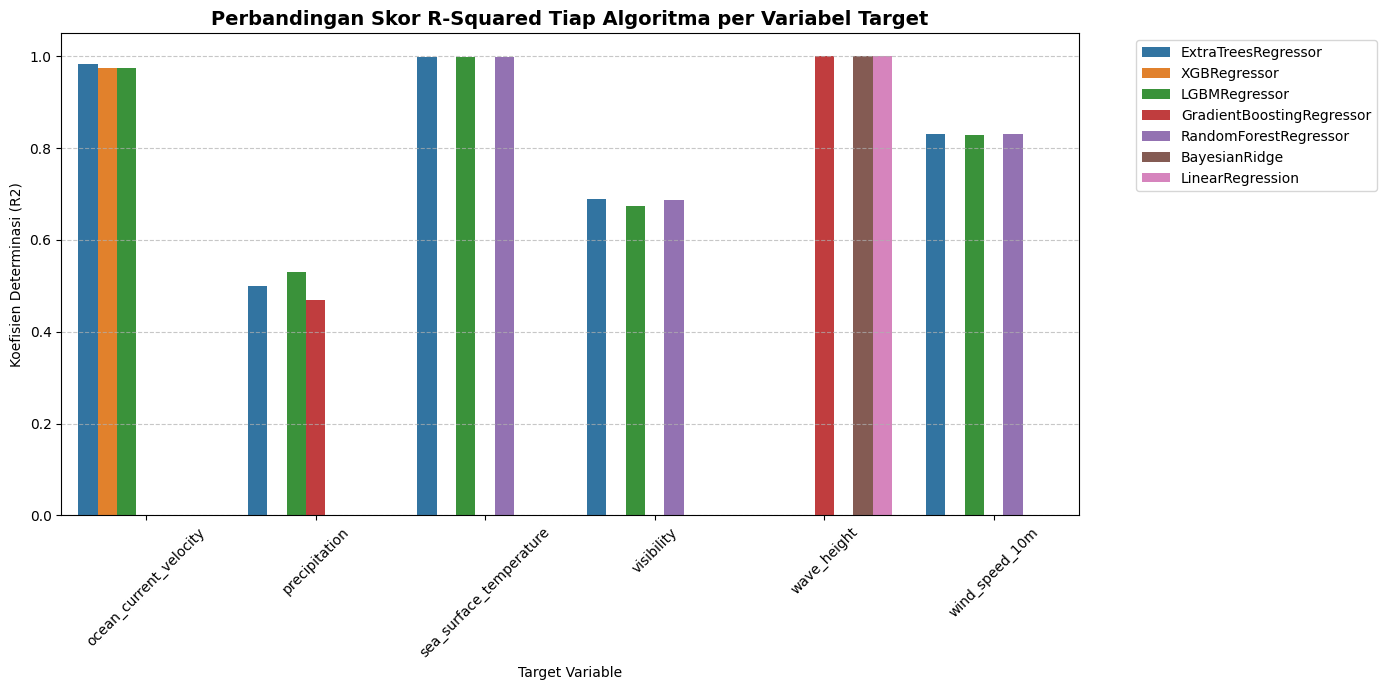


--- MENGHASILKAN KURVA PEMBELAJARAN UNTUK MODEL TERBAIK ---

Memproses Kurva Pembelajaran: wave_height (LinearRegression)...


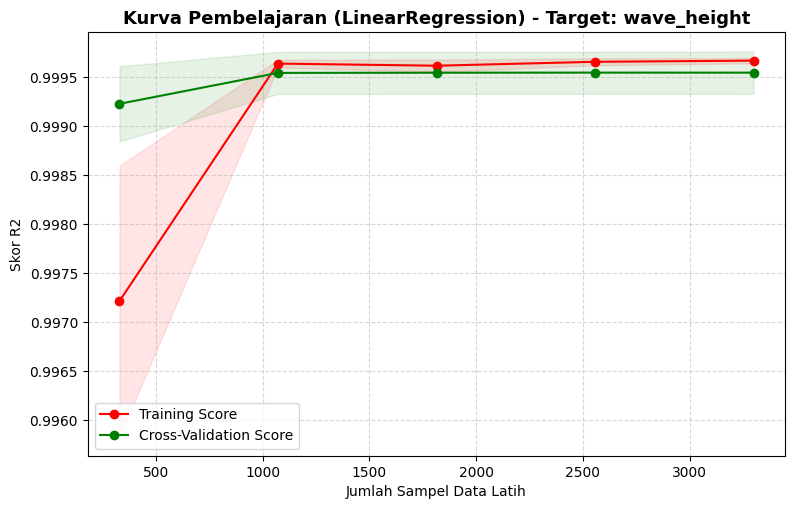

 -> [SUKSES] Grafik disimpan: learning_curve_wave_height.png

Memproses Kurva Pembelajaran: wind_speed_10m (LGBMRegressor)...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000836 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 816
[LightGBM] [Info] Number of data points in the train set: 330, number of used features: 18
[LightGBM] [Info] Start training from score 7.745758
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] 

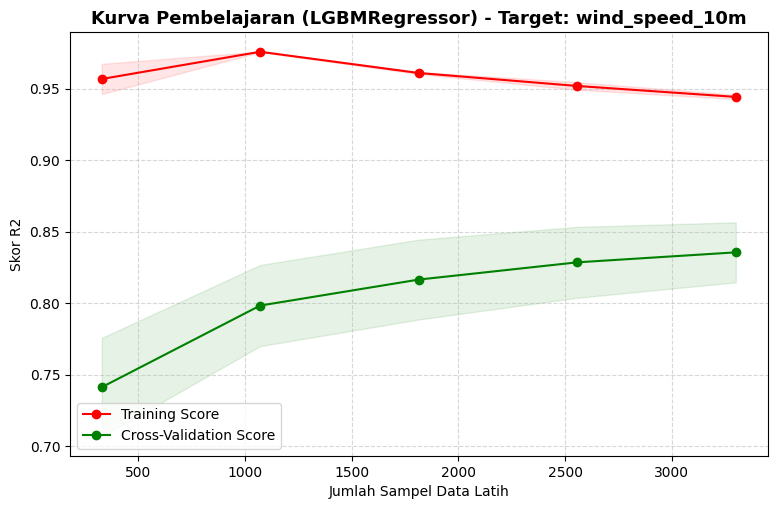

 -> [SUKSES] Grafik disimpan: learning_curve_wind_speed_10m.png

Memproses Kurva Pembelajaran: ocean_current_velocity (ExtraTreesRegressor)...


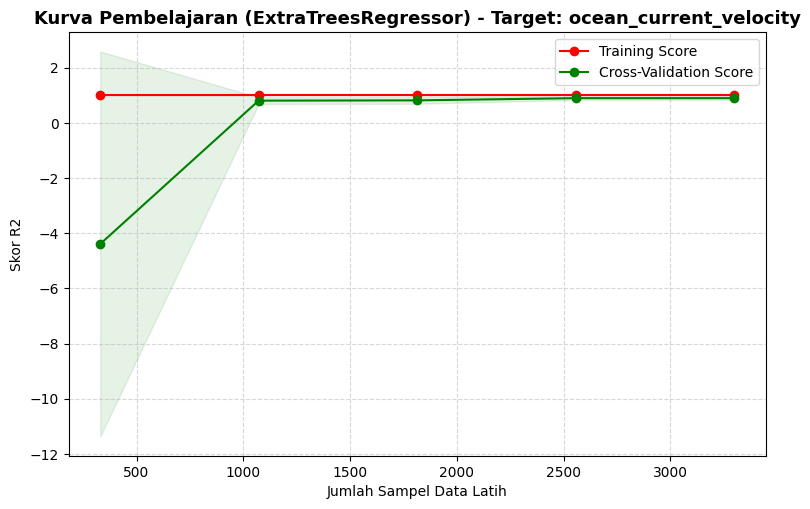

 -> [SUKSES] Grafik disimpan: learning_curve_ocean_current_velocity.png

Memproses Kurva Pembelajaran: sea_surface_temperature (ExtraTreesRegressor)...


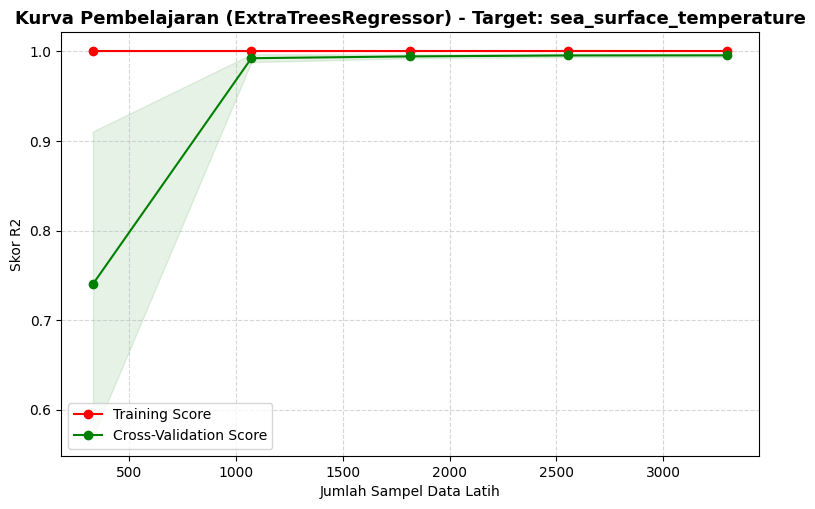

 -> [SUKSES] Grafik disimpan: learning_curve_sea_surface_temperature.png

Memproses Kurva Pembelajaran: precipitation (GradientBoostingRegressor)...


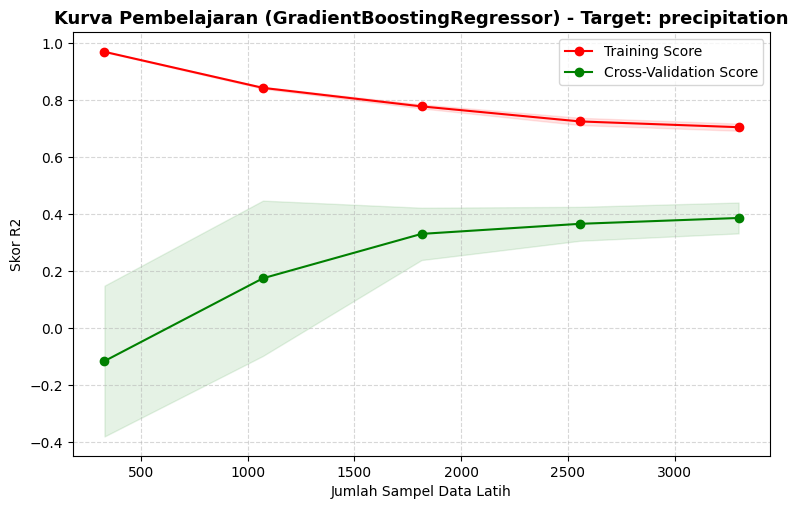

 -> [SUKSES] Grafik disimpan: learning_curve_precipitation.png

Memproses Kurva Pembelajaran: visibility (RandomForestRegressor)...


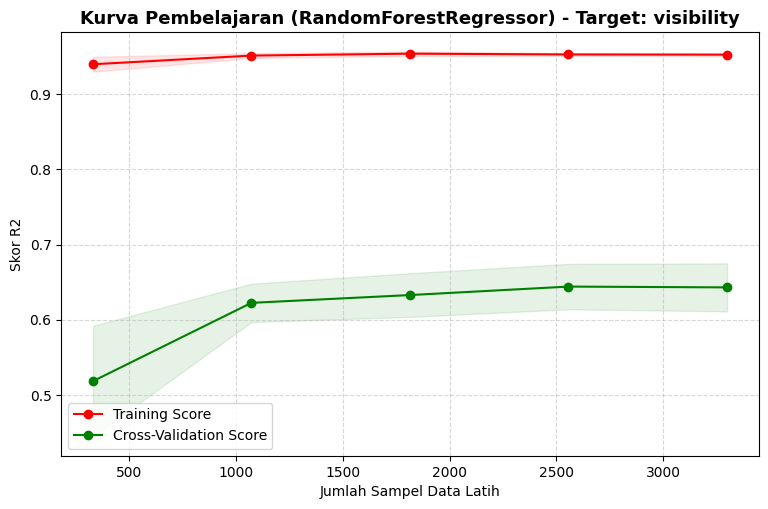

 -> [SUKSES] Grafik disimpan: learning_curve_visibility.png

--- SELURUH EVALUASI SELESAI ---


In [23]:
# =====================================================================
# SEL 4: VISUALISASI PERBANDINGAN & LEARNING CURVES
# =====================================================================
# 1. Barplot Perbandingan R2
plt.figure(figsize=(14, 7))
sns.barplot(data=metrics_df, x="Target Variable", y="R2", hue="Algorithm")
plt.title("Perbandingan Skor R-Squared Tiap Algoritma per Variabel Target", fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel("Koefisien Determinasi (R2)")
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 2. Generasi Kurva Pembelajaran (Learning Curves)
print("\n--- MENGHASILKAN KURVA PEMBELAJARAN UNTUK MODEL TERBAIK ---")

for target_var, models in target_configs.items():
    if not models:
        continue
        
    model_eval = models[0] # Ekstraksi model peringkat 1
    model_name = model_eval.__class__.__name__
    print(f"\nMemproses Kurva Pembelajaran: {target_var} ({model_name})...")
    
    pipeline_eval = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')), 
        ('model', model_eval)
    ])
    
    y_eval = df[target_var]
    
    try:
        train_sizes, train_scores, test_scores = learning_curve(
            estimator=pipeline_eval,
            X=X_clean,
            y=y_eval,
            train_sizes=np.linspace(0.1, 1.0, 5),
            cv=5,
            scoring='r2',
            n_jobs=1,
            random_state=123
        )
        
        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        test_mean = np.mean(test_scores, axis=1)
        test_std = np.std(test_scores, axis=1)
        
        plt.figure(figsize=(9, 5.5))
        plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training Score")
        plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
        plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-Validation Score")
        plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")
        
        plt.title(f"Kurva Pembelajaran ({model_name}) - Target: {target_var}", fontsize=13, fontweight='bold')
        plt.xlabel("Jumlah Sampel Data Latih")
        plt.ylabel("Skor R2")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.legend(loc="best")
        
        filename = f"learning_curve_{target_var}.png"
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.show()
        print(f" -> [SUKSES] Grafik disimpan: {filename}")
        
    except Exception as e:
        print(f" -> [GAGAL] Kendala pada {target_var}: {e}")

print("\n--- SELURUH EVALUASI SELESAI ---")